# 03 — Data Explorer

A hands-on look at what `events_clean.parquet` actually contains.
We print real sessions, event distributions, and flag patterns that look like noise.

In [1]:
import pandas as pd
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

CLEAN_PARQUET = "/home/mofu/code/thesis/pipeline/output/events_clean.parquet"

df = pd.read_parquet(CLEAN_PARQUET)
print(f"Loaded {len(df):,} rows")
df.head(3)

Loaded 210,321,217 rows


,client_id,timestamp,event_type,sku,session_id
0,0,2022-06-29 10:24:15,page_visit,NaN,1
1,1,2022-06-29 11:02:10,page_visit,NaN,2
2,1,2022-06-29 11:02:15,add_to_cart,66364.0,2


## Schema & basic stats

In [2]:
print("dtypes:")
print(df.dtypes)
print()
print(f"Date range  : {df.timestamp.min()}  →  {df.timestamp.max()}")
print(f"Unique users: {df.client_id.nunique():,}")
print(f"Sessions    : {df.session_id.nunique():,}")
print(f"Events      : {len(df):,}")
print()
print("Event type counts:")
display(df.event_type.value_counts().rename("count").to_frame())

dtypes:
client_id              int64
timestamp     datetime64[us]
event_type               str
sku                  float64
session_id             int32
dtype: object



Date range  : 2022-06-23 00:10:00  →  2022-12-01 03:48:30


Unique users: 21,349,246


Sessions    : 51,522,120
Events      : 210,321,217

Event type counts:


,count
event_type,
page_visit,187683645
search_query,11649993
add_to_cart,6855719
remove_from_cart,2325119
product_buy,1806741


## Print a handful of real sessions

These are the raw rows a user generates in one sitting (gap < 30 min).

In [3]:
# Pick sessions that have at least one item-bearing event so they're interesting
item_sessions = df[df.event_type.isin(['add_to_cart','remove_from_cart','product_buy'])]['session_id'].unique()

# Sample a variety: short, medium, longer
sess_len = df.groupby('session_id').size().rename('n_events')
interesting = sess_len[sess_len.index.isin(item_sessions)]

short_ids  = interesting[interesting <= 3].sample(3, random_state=1).index
medium_ids = interesting[(interesting >= 5) & (interesting <= 10)].sample(3, random_state=1).index
long_ids   = interesting[interesting >= 15].sample(2, random_state=1).index

chosen = list(short_ids) + list(medium_ids) + list(long_ids)

for sid in chosen:
    sess = df[df.session_id == sid].sort_values('timestamp')
    client = sess.client_id.iloc[0]
    dur = (sess.timestamp.max() - sess.timestamp.min()).total_seconds()
    print(f"\n{'='*70}")
    print(f"session_id={sid}  client_id={client}  events={len(sess)}  duration={dur:.0f}s")
    print('='*70)
    display(
        sess[['timestamp','event_type','sku']]
        .assign(
            delta_s=sess['timestamp'].diff().dt.total_seconds().round(0),
            sku=sess['sku'].apply(lambda x: int(x) if pd.notna(x) else '')
        )
        .reset_index(drop=True)
    )


session_id=8027549  client_id=3517412  events=3  duration=25s


,timestamp,event_type,sku,delta_s
0,2022-08-16 07:13:35,page_visit,,NaN
1,2022-08-16 07:14:00,page_visit,,25.0
2,2022-08-16 07:14:00,add_to_cart,64760,0.0



session_id=45687900  client_id=20017234  events=1  duration=0s


,timestamp,event_type,sku,delta_s
0,2022-11-23 10:53:20,product_buy,408528,NaN



session_id=23589436  client_id=10337479  events=1  duration=0s


...

,timestamp,event_type,sku,delta_s
0,2022-09-01 10:44:15,add_to_cart,492082,NaN
1,2022-09-01 10:44:15,page_visit,,0.0
2,2022-09-01 10:45:20,page_visit,,65.0
3,2022-09-01 10:45:25,remove_from_cart,1305727,5.0
4,2022-09-01 10:45:30,remove_from_cart,492082,5.0
5,2022-09-01 10:45:35,page_visit,,5.0
6,2022-09-01 10:45:35,page_visit,,0.0
7,2022-09-01 10:47:00,page_visit,,85.0



session_id=938041  client_id=410765  events=20  duration=365s


,timestamp,event_type,sku,delta_s
0,2022-10-13 18:38:35,page_visit,,NaN
1,2022-10-13 18:39:15,page_visit,,40.0
2,2022-10-13 18:39:25,add_to_cart,1485525,10.0
3,2022-10-13 18:40:00,page_visit,,35.0
4,2022-10-13 18:40:00,page_visit,,0.0
5,2022-10-13 18:40:00,search_query,,0.0
6,2022-10-13 18:40:35,page_visit,,35.0
7,2022-10-13 18:40:40,add_to_cart,1366214,5.0
8,2022-10-13 18:40:45,page_visit,,5.0
9,2022-10-13 18:41:20,page_visit,,35.0



session_id=10903509  client_id=4777788  events=41  duration=435s


,timestamp,event_type,sku,delta_s
0,2022-08-22 18:00:15,page_visit,,NaN
1,2022-08-22 18:00:15,page_visit,,0.0
2,2022-08-22 18:00:40,page_visit,,25.0
3,2022-08-22 18:01:05,page_visit,,25.0
4,2022-08-22 18:01:05,page_visit,,0.0
5,2022-08-22 18:01:25,page_visit,,20.0
6,2022-08-22 18:01:25,page_visit,,0.0
7,2022-08-22 18:01:45,page_visit,,20.0
8,2022-08-22 18:01:50,page_visit,,5.0
9,2022-08-22 18:01:55,page_visit,,5.0


## Session length distribution

How many events does a typical session contain?

Session length percentiles:


  p 25: 1 events


  p 50: 1 events


  p 75: 3 events


  p 90: 8 events


  p 95: 15 events


  p 99: 43 events


  p100: 5274 events
  mean: 4.08 events
  sessions with length=1: 28,315,754 (55.0%)


  sessions with length=2: 6,150,325 (11.9%)


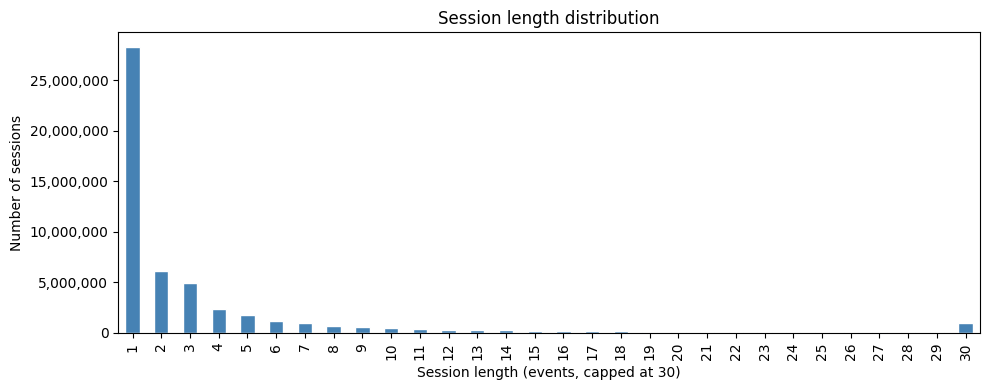

In [4]:
sess_len = df.groupby('session_id').size().rename('n_events')

print("Session length percentiles:")
for p in [25, 50, 75, 90, 95, 99, 100]:
    print(f"  p{p:>3}: {sess_len.quantile(p/100):.0f} events")
print(f"  mean: {sess_len.mean():.2f} events")
print(f"  sessions with length=1: {(sess_len==1).sum():,} ({(sess_len==1).mean()*100:.1f}%)")
print(f"  sessions with length=2: {(sess_len==2).sum():,} ({(sess_len==2).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
sess_len.clip(upper=30).value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Session length (events, capped at 30)')
ax.set_ylabel('Number of sessions')
ax.set_title('Session length distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## What do single-event sessions look like?

A user who triggers exactly one event and leaves — these are the clearest noise candidates.

In [5]:
single = df[df['session_id'].isin(sess_len[sess_len == 1].index)]
print(f"Single-event sessions: {len(single):,}")
print()
print("Event type breakdown:")
display(single['event_type'].value_counts().rename('count').to_frame())

print("\n5 random single-event sessions:")
display(
    single[['client_id','session_id','timestamp','event_type','sku']]
    .sample(5, random_state=42)
    .reset_index(drop=True)
)

Single-event sessions: 28,315,754

Event type breakdown:


,count
event_type,
page_visit,27854121
product_buy,320566
search_query,71840
add_to_cart,52264
remove_from_cart,16963



5 random single-event sessions:


,client_id,session_id,timestamp,event_type,sku
0,4421397,10092930,2022-09-04 22:41:40,page_visit,NaN
1,7684290,17534123,2022-11-05 12:18:55,page_visit,NaN
2,20519085,46841645,2022-11-05 10:12:30,page_visit,NaN
3,23015611,52537853,2022-09-09 10:51:50,page_visit,NaN
4,9217706,21028317,2022-10-11 13:08:00,page_visit,NaN


## Suspicious patterns — potential noise

Things that are hard to explain as intentional human behaviour.

In [6]:
# 1. Add-to-cart immediately followed by remove-from-cart on the same SKU
item_events = df[df.event_type.isin(['add_to_cart','remove_from_cart','product_buy'])].copy()
item_events = item_events.sort_values(['client_id','timestamp'])
item_events['next_event'] = item_events.groupby('session_id')['event_type'].shift(-1)
item_events['next_sku']   = item_events.groupby('session_id')['sku'].shift(-1)
item_events['delta_next'] = item_events.groupby('session_id')['timestamp'].diff(-1).abs().dt.total_seconds()

add_then_remove = item_events[
    (item_events.event_type == 'add_to_cart') &
    (item_events.next_event == 'remove_from_cart') &
    (item_events.sku == item_events.next_sku)
]
print(f"add_to_cart → remove_from_cart (same SKU, same session): {len(add_then_remove):,}")
print(f"  of these with delta < 5s: {(add_then_remove.delta_next < 5).sum():,}")

print()

# 2. Users with very high event counts (potential bots)
user_events = df.groupby('client_id').size().rename('total_events').sort_values(ascending=False)
print("Top 10 users by total event count (bot candidates):")
display(user_events.head(10).to_frame())

print()

# 3. Exact duplicate timestamps within a session
dups = df[df.duplicated(subset=['client_id','timestamp','event_type'], keep=False)]
print(f"Rows with duplicate (client, timestamp, event_type): {len(dups):,}")
print("  (preprocess.py dedupes on (client, timestamp, sku) for item events, but not cross event types)")

add_to_cart → remove_from_cart (same SKU, same session): 647,670
  of these with delta < 5s: 17,421



Top 10 users by total event count (bot candidates):


,total_events
client_id,
3818841,49872
19629850,37200
11431224,27344
17873087,26743
23439416,24904
6573244,24560
9252426,23354
13731357,22883
8108457,21647


Rows with duplicate (client, timestamp, event_type): 51,233,885
  (preprocess.py dedupes on (client, timestamp, sku) for item events, but not cross event types)


## A 'buy without cart' session

Sessions that go directly to `product_buy` without any prior `add_to_cart` — could be 1-click buy, or could be a logging artefact.

In [7]:
buy_sessions = set(df[df.event_type == 'product_buy']['session_id'])
atc_sessions = set(df[df.event_type == 'add_to_cart']['session_id'])
buy_no_cart  = buy_sessions - atc_sessions

print(f"Sessions with product_buy but NO add_to_cart: {len(buy_no_cart):,} "
      f"({len(buy_no_cart)/len(buy_sessions)*100:.1f}% of buy sessions)")

print("\n3 example sessions:")
sample_ids = list(buy_no_cart)[:3]
for sid in sample_ids:
    sess = df[df.session_id == sid].sort_values('timestamp')
    print(f"\nsession_id={sid}  events={len(sess)}")
    display(
        sess[['timestamp','event_type','sku']]
        .assign(sku=sess['sku'].apply(lambda x: int(x) if pd.notna(x) else ''))
        .reset_index(drop=True)
    )

Sessions with product_buy but NO add_to_cart: 523,067 (42.0% of buy sessions)

3 example sessions:



session_id=3145728  events=51


,timestamp,event_type,sku
0,2022-07-11 19:07:25,page_visit,
1,2022-07-11 19:07:30,page_visit,
2,2022-07-11 19:07:55,page_visit,
3,2022-07-11 19:08:00,page_visit,
4,2022-07-11 19:08:10,page_visit,
5,2022-07-11 19:08:15,page_visit,
6,2022-07-11 19:08:25,page_visit,
7,2022-07-11 19:08:30,page_visit,
8,2022-07-11 19:09:05,page_visit,
9,2022-07-11 19:09:45,remove_from_cart,212456



session_id=44040193  events=9


,timestamp,event_type,sku
0,2022-10-29 14:49:55,page_visit,
1,2022-10-29 14:49:55,page_visit,
2,2022-10-29 14:49:55,page_visit,
3,2022-10-29 14:50:00,page_visit,
4,2022-10-29 14:50:05,page_visit,
5,2022-10-29 14:51:20,product_buy,935917
6,2022-10-29 14:52:35,page_visit,
7,2022-10-29 14:52:40,page_visit,
8,2022-10-29 14:52:45,page_visit,



session_id=38797315  events=11


,timestamp,event_type,sku
0,2022-10-26 13:14:45,page_visit,
1,2022-10-26 13:16:05,page_visit,
2,2022-10-26 13:16:05,page_visit,
3,2022-10-26 13:16:25,page_visit,
4,2022-10-26 13:16:35,page_visit,
5,2022-10-26 13:17:20,page_visit,
6,2022-10-26 13:17:25,page_visit,
7,2022-10-26 13:19:35,product_buy,1582521
8,2022-10-26 13:19:40,page_visit,
9,2022-10-26 13:20:25,page_visit,


## Inter-event delta distribution

How fast do events arrive within a session? Sub-second events are suspicious.

Intra-session delta (seconds) percentiles:


  p 1: 0.00s


  p 5: 0.00s


  p25: 4.00s


  p50: 10.00s


  p75: 39.00s


  p90: 114.00s


  p95: 235.00s


  p99: 985.00s



Deltas < 1s  : 38,179,590 (24.04%)
Deltas == 0s : 38,179,590


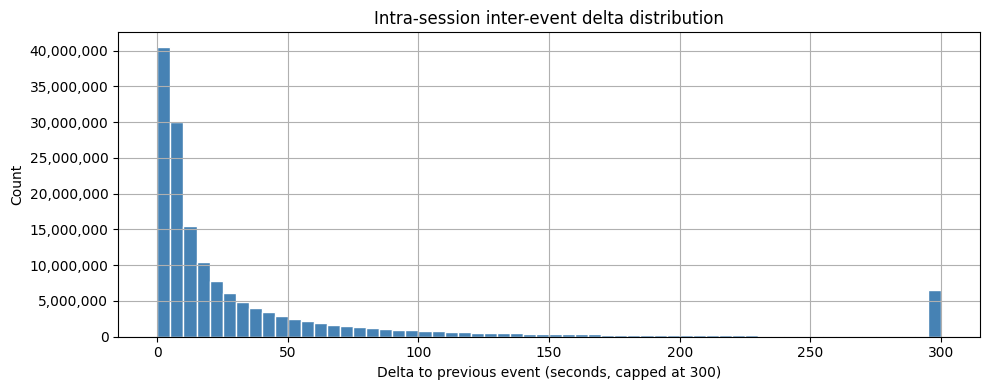

In [8]:
deltas = (
    df.sort_values(['session_id','timestamp'])
    .groupby('session_id')['timestamp']
    .diff()
    .dt.total_seconds()
    .dropna()
)

print("Intra-session delta (seconds) percentiles:")
for p in [1, 5, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {deltas.quantile(p/100):.2f}s")

print(f"\nDeltas < 1s  : {(deltas < 1).sum():,} ({(deltas < 1).mean()*100:.2f}%)")
print(f"Deltas == 0s : {(deltas == 0).sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
deltas.clip(upper=300).hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Delta to previous event (seconds, capped at 300)')
ax.set_ylabel('Count')
ax.set_title('Intra-session inter-event delta distribution')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## Summary — where 'noise' comes from

| Pattern | Likely cause |
|---|---|
| Single-event sessions (mostly `page_visit`) | Bounced visits, scrapers, preloaders |
| add_to_cart → remove_from_cart in < 5s | Accidental tap, UI glitch |
| Duplicate (client, timestamp, event_type) | Retry logging on unstable connections |
| product_buy with no prior add_to_cart | Logging artefact or 1-click buy (ambiguous) |
| Zero-second deltas | Batch flush from client SDK |
| Power users with 10k+ events | Bot traffic / internal testing accounts |

The transformer learns these patterns too — it's trained on all of them.
GRU4Rec then tries to **generalize** across both real behaviour and noise,
which is why TRTR val loss rises from epoch 1: there isn't a clean signal to latch onto.
Synthetic sessions come from a model that averaged across the whole distribution,
so the noisiest individual cases get smoothed away — giving GRU4Rec a cleaner training set.